In [40]:
# 1. Import Dependencies
import pandas as pd
import numpy as np
import random
from sklearn.svm import SVR
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import KFold
import matplotlib.pyplot as plt

In [41]:
# Load the dataset
df = pd.read_csv("extracted_columns.csv")

# Prepare features and target
X = df[['PSS-1', 'PSS-2', 'PSS-3', 'PSS-4', 'PSS-5', 'PSS-6', 'PSS-7',
        'PSS-8', 'PSS-9', 'PSS-10', 'PSS-11', 'PSS-12', 'PSS-13', 'PSS-14']]
df['PSS_total'] = X.sum(axis=1)
y = df['PSS_total']

In [42]:
# Define evaluation and plotting function
def evaluate_and_plot(model_name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    print(f"{model_name} RMSE: {rmse:.4f}")
    print(f"{model_name} MAE: {mae:.4f}")
    print(f"{model_name} R^2: {r2:.4f}")
    
    plt.figure(figsize=(8,6))
    plt.scatter(y_true, y_pred, alpha=0.6)
    plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--')
    plt.xlabel('Actual Values')
    plt.ylabel('Predicted Values')
    plt.title(f'{model_name}: Actual vs Predicted')
    plt.show()

In [43]:
# SVR fitness function using kfold cross-validation
def fitness_kfold_svr(individual, X, y, k=5):
    kf = KFold(n_splits=k, shuffle=True, random_state=42)
    rmse_scores = []
    for train_idx, val_idx in kf.split(X):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
        model = make_pipeline(
            StandardScaler(),
            SVR(C=individual['C'], epsilon=individual['epsilon'], kernel=individual['kernel'])
        )
        model.fit(X_train, y_train)
        preds = model.predict(X_val)
        rmse_scores.append(np.sqrt(mean_squared_error(y_val, preds)))
    return -np.mean(rmse_scores)

In [48]:
# New function to run multiple GA optimizations and plot results
def multiple_ga_runs(X, y, runs=30):
    results = []

    for run in range(runs):
        print(f"\n=== GA Run {run+1}/{runs} ===")
        seed = 42 + run
        random.seed(seed)
        np.random.seed(seed)

        best_params = genetic_algorithm_kfold_svr(X, y)

        model = make_pipeline(
            StandardScaler(),
            SVR(C=best_params['C'], epsilon=best_params['epsilon'], kernel=best_params['kernel'])
        )
        model.fit(X, y)
        preds = model.predict(X)

        rmse = np.sqrt(mean_squared_error(y, preds))
        mae = mean_absolute_error(y, preds)
        r2 = r2_score(y, preds)

        results.append({
    'Run': run+1,
    'Seed': seed,
    'C': best_params['C'],
    'epsilon': best_params['epsilon'],
    'kernel': best_params['kernel'],
    'RMSE': rmse,
    'MAE': mae,
    'R2': r2
})

        print(f"Run {run+1} Metrics -> RMSE: {rmse:.4f}, MAE: {mae:.4f}, R^2: {r2:.4f}")

    rmse_vals = [r['RMSE'] for r in results]
    mae_vals = [r['MAE'] for r in results]
    r2_vals = [r['R2'] for r in results]

    print("\n=== Final 30-Run Summary ===")
    print(f"Average RMSE: {np.mean(rmse_vals):.4f} ± {np.std(rmse_vals):.4f}")
    print(f"Average MAE: {np.mean(mae_vals):.4f} ± {np.std(mae_vals):.4f}")
    print(f"Average R^2: {np.mean(r2_vals):.4f} ± {np.std(r2_vals):.4f}")

    import pandas as pd
    results_df = pd.DataFrame(results)
    results_df.to_csv("GA_SVR_30_Run_Results.csv", index=False)

    plt.figure(figsize=(12,6))
    plt.subplot(1, 3, 1)
    plt.boxplot(rmse_vals)
    plt.title("RMSE Distribution")
    plt.ylabel("RMSE")

    plt.subplot(1, 3, 2)
    plt.boxplot(mae_vals)
    plt.title("MAE Distribution")
    plt.ylabel("MAE")

    plt.subplot(1, 3, 3)
    plt.boxplot(r2_vals)
    plt.title("R^2 Distribution")
    plt.ylabel("R^2")

    plt.suptitle("GA-Optimized SVR Performance over Multiple Runs")
    plt.tight_layout()
    plt.show()

    return results_df


=== GA Run 1/30 ===
Generation 1, Best RMSE: 0.0617, Params: {'C': 758.8314863930543, 'epsilon': 0.14814254923989248, 'kernel': 'linear', 'fitness': np.float64(-0.06171094673183626)}
Generation 2, Best RMSE: 0.0617, Params: {'C': 758.8314863930543, 'epsilon': 0.14814254923989248, 'kernel': 'linear', 'fitness': np.float64(-0.06171094673183626)}
Generation 3, Best RMSE: 0.0617, Params: {'C': 244.96736461809587, 'epsilon': 0.14814254923989248, 'kernel': 'linear', 'fitness': np.float64(-0.06171094673183626)}
Generation 4, Best RMSE: 0.0631, Params: {'C': 244.96736461809587, 'epsilon': np.float64(0.1515560581666588), 'kernel': 'linear', 'fitness': np.float64(-0.06311089217652291)}
Generation 5, Best RMSE: 0.0617, Params: {'C': 561.2889384323191, 'epsilon': 0.14814254923989248, 'kernel': 'linear', 'fitness': np.float64(-0.06171094673183626)}
Generation 6, Best RMSE: 0.0617, Params: {'C': 162.73783174636918, 'epsilon': 0.14814254923989248, 'kernel': 'linear', 'fitness': np.float64(-0.0617109

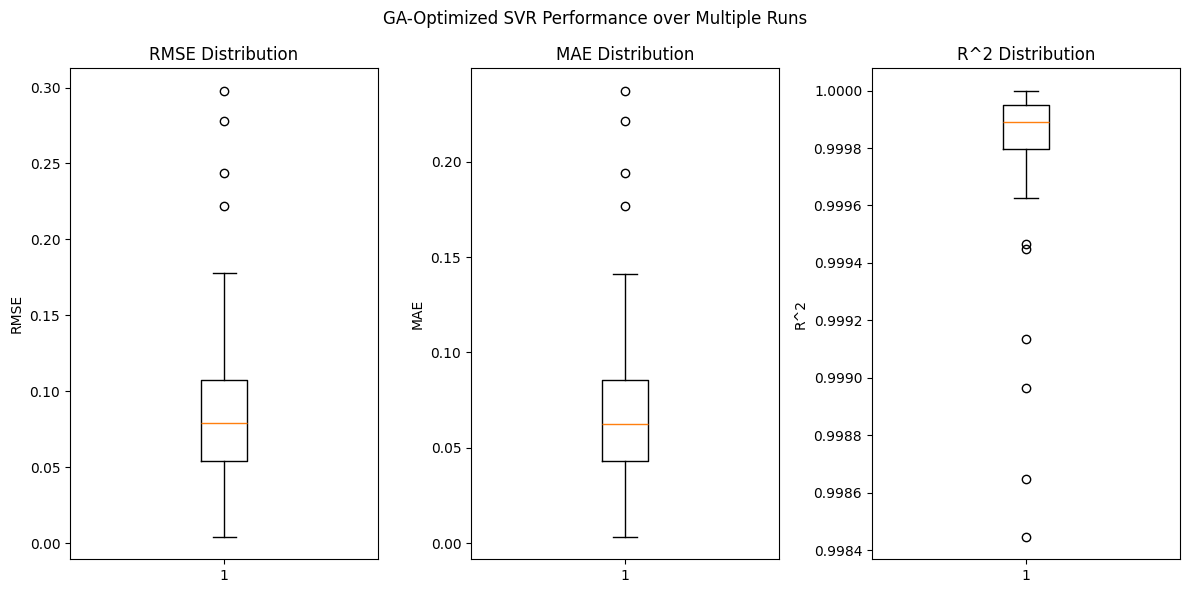

In [49]:
# Run multiple GA experiments to finalize the hyperparameters
results_df = multiple_ga_runs(X, y, runs=30)

In [52]:
# Select best parameters from run with lowest RMSE
best_run = results_df.iloc[results_df['RMSE'].idxmin()]
best_params = {
    'C': best_run['C'],
    'epsilon': best_run['epsilon'],
    'kernel': best_run['kernel']
}
print(f"Best hyperparameters: {best_params}")



Best hyperparameters: {'C': np.float64(767.8111761399769), 'epsilon': np.float64(0.01), 'kernel': 'linear'}


In [53]:
# Train final SVR pipeline on entire dataset
final_svr_model = make_pipeline(
    StandardScaler(),
    SVR(C=best_params['C'], epsilon=best_params['epsilon'], kernel=best_params['kernel'])
)
final_svr_model.fit(X, y)



,steps,"[('standardscaler', ...), ('svr', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0


Final GA-Optimized SVR on Validation Set RMSE: 0.0044
Final GA-Optimized SVR on Validation Set MAE: 0.0035
Final GA-Optimized SVR on Validation Set R^2: 1.0000


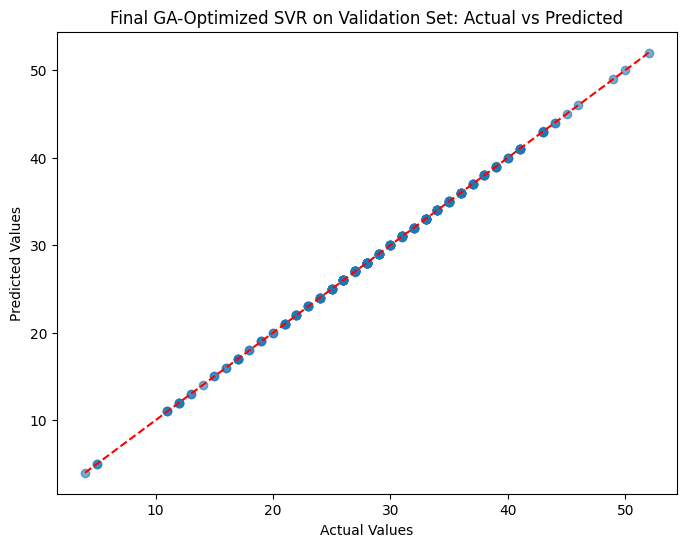

In [55]:
from sklearn.model_selection import train_test_split

# Evaluate final model on a held-out test set
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
final_svr_model.fit(X_train, y_train)
y_pred = final_svr_model.predict(X_val)
evaluate_and_plot('Final GA-Optimized SVR on Validation Set', y_val, y_pred)